In [1]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [6]:
#load the dataset
df = pd.read_csv(r'C:\Users\Soham Deshmukh\Desktop\B.Tech\ADS\ADS-PEIT412B\Assignment_2\data\customer_churn_dataset-training-master.csv')
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [13]:
#performing EDA on the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


In [12]:
df.dropna()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [14]:
#checking for missing values
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

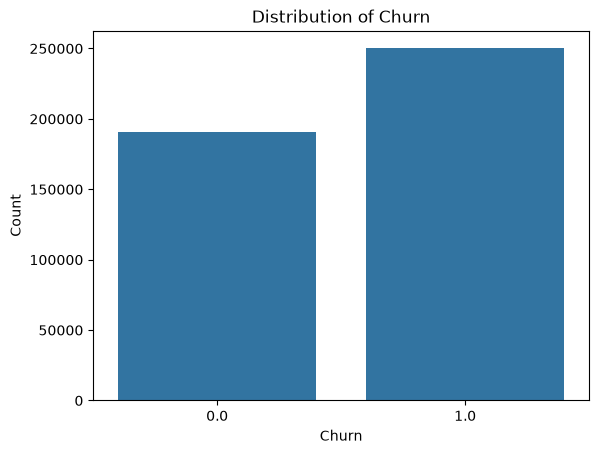

In [15]:
#graph on churn
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [16]:
#feature/target split
X= df.drop('Churn', axis=1)
y= df['Churn']


In [21]:
#train-test split and scaling
# remove rows with missing values and update X, y
df = df.dropna()
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
# encode categorical columns and align train/test, then fit scaler on X_train
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
# 4. Build ANN with Dropout + Batch Normalization
model = Sequential([

Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
BatchNormalization(),
Dropout(0.3),
Dense(32, activation='relu'),
BatchNormalization(),
Dropout(0.3),
Dense(1, activation='sigmoid') # binary classification output
])

c:\Users\Soham Deshmukh\Desktop\B.Tech\ADS\ADS-PEIT412B\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
# 5. Compile with chosen optimizer
model.compile(optimizer=Adam(learning_rate=0.001),
loss='binary_crossentropy',
metrics=['accuracy'])

In [25]:
# 6. Train with Early Stopping
es = EarlyStopping(monitor='val_loss', patience=5,
restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=20, batch_size=32,
validation_split=0.2, callbacks=[es])

Epoch 1/20
8817/8817 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.9944 - loss: 0.0150 - val_accuracy: 0.9966 - val_loss: 0.0077
Epoch 2/20
8817/8817 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.9944 - loss: 0.0150 - val_accuracy: 0.9960 - val_loss: 0.0090
Epoch 3/20
8817/8817 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9944 - loss: 0.0148 - val_accuracy: 0.9965 - val_loss: 0.0076
Epoch 4/20
8817/8817 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - accuracy: 0.9945 - loss: 0.0147 - val_accuracy: 0.9968 - val_loss: 0.0077
Epoch 5/20
8817/8817 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9947 - loss: 0.0141 - val_accuracy: 0.9971 - val_loss: 0.0072
Epoch 6/20
8817/8817 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.9948 - loss: 0.0139 - val_accuracy: 0.9964 - val_loss: 0.0080
Epoch 7/20
8817/8817 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.9947 - loss: 0.0135 - val_accuracy: 0.9967 - val_loss: 0.0073
Epoch 8/20
8817/8817 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - accuracy: 0.9950 - loss: 0

In [26]:
# 7. Evaluate the model
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

2756/2756 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
[[38038   129]
 [   74 49926]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38167
         1.0       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



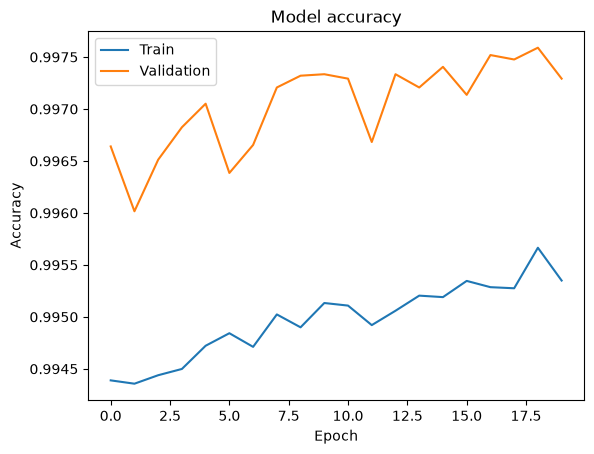

In [27]:
#Evaluation graphs
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()